# Práctica 3: IA en salud

## Interpretabilidad de modelos CNN en clasificación de retinopatía diabéticas

### 1. Introducción

En este notebook se aborda el problema de la interpretabilidad en modelos de aprendizaje profundo aplicados a imágenes médicas, concretamente en la clasificación de retinopatía diabética a partir de imágenes de fondo de ojo.

Las redes neuronales convolucionales (CNN) han demostrado un alto rendimiento en tareas de clasificación visual; sin embargo, su naturaleza de "caja negra" dificulta la comprensión de las decisiones que toman. Este aspecto es especialmente crítico en el ámbito clínico, donde la explicabilidad del modelo es fundamental para generar confianza y facilitar su adopción en la práctica médica.

El objetivo de este trabajo es analizar y comparar distintos métodos de interpretabilidad visual aplicados a un modelo basado en EfficientNet entrenado para la detección de retinopatía diabética en tareas de clasificación binaria y multiclase.

En particular, se estudiarán los siguientes métodos:
* Grad-CAM
* Grad-CAM++
* Integrated Gradients

Estos métodos permiten identificar las regiones de la imagen que más influyen en la predicción del modelo, proporcionando información relevante sobre su comportamiento interno.

A lo largo del notebook, se generarán mapas de activación para diferentes imágenes, se compararán los resultados entre métodos y se analizará su coherencia con las características clínicas de la enfermedad.

### 2. Configuración

En primer lugar, se instalarán los paquetes necesarios para realizar esta parte de la práctica.

In [17]:
!pip install grad-cam opencv-python torch torchvision


En esta primera sección también se definirán las variables de configuración, tales como las rutas de los datos, parámetros globales del experimento y el dispositivo de cómputo (CPU/GPU).

Se trabajará con dos tareas:
* Clasificación binaria: presencia o ausencia de retinopatía diabética.
* Clasificación multiclase: cinco niveles de severidad.

También se definen diccionarios para la interpretación de las predicciones del modelo.

In [18]:
from pathlib import Path
import torch

TRAIN_DIR      = Path('4864-train')
TEST_DIR       = Path('1216-test')
CHECKPOINT_DIR = Path('checkpoints')
IMG_SIZE       = 224
DEVICE         = 'cuda' if torch.cuda.is_available() else 'cpu'

GRADES        = {0: 'Sin RD', 1: 'Leve', 2: 'Moderada',
                 3: 'Severa', 4: 'Proliferativa'}
BINARY_LABELS = {0: 'Sin RD', 1: 'Con RD'}

print(f'Device: {DEVICE}')

Device: cpu


### 3. Preprocesamiento de las imágenes

Antes de pasarle una imagen al modelo que estemos usando tendremos que:
1. Redimensionarla al tamaño que espera la red (224x224).
2. Normalizarla con los mismos valores que en entrenamiento.

Así pues, la función `preprocess_image` devolverá dos cosas:
- `input_tensor`: lo que recibirá el modelo (normalizado)
- `img_float`: la imagen original [0,1] para el overlay visual

In [19]:
import numpy as np
import cv2

import albumentations as A
from albumentations.pytorch import ToTensorV2

def preprocess_image(img_path: str):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w   = img.shape[:2]
    scale  = IMG_SIZE / h
    new_w  = int(w * scale)
    img    = cv2.resize(img, (new_w, IMG_SIZE),
                        interpolation=cv2.INTER_LANCZOS4)
    x      = (new_w - IMG_SIZE) // 2
    img    = img[:, x:x + IMG_SIZE]

    img_float = np.float32(img) / 255.0

    transform = A.Compose([
        A.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])
    input_tensor = transform(image=img)['image'].unsqueeze(0)

    return input_tensor, img_float

### 4. Carga de los modelos a estudiar

A continuación, definiremos la función `load_model`, que será la encargada de reconstruir la arquitectura de los modelos que se entrenaron en el notebook de clasificación `p3_clasificación.ipynb` y cargará los pesos guardados durante el entrenamiento de los mismos.

Además, se identifican las capas objetivo necesarias para la generación de mapas de activación mediante técnicas como Grad-CAM.

In [20]:
import torch.nn as nn
from torchvision import models

def load_model(task: str):
    """
    task: 'binary' o 'multiclass'
    Devuelve el modelo cargado y la capa objetivo para CAM
    """
    num_classes = 2 if task == 'binary' else 5
    out_features = 1 if task == 'binary' else num_classes

    model = models.efficientnet_b3(weights=None)
    model.classifier = nn.Sequential(
        nn.Linear(1536, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(512, out_features)
    )

    checkpoint = CHECKPOINT_DIR / f'best_model_{task}.pth'
    model.load_state_dict(torch.load(checkpoint,
                                      map_location=DEVICE))
    model = model.to(DEVICE)
    model.eval()
    
    target_layers = [model.features[-1]]

    print(f'Modelo {task} cargado desde {checkpoint}')
    return model, target_layers

model_binary,     layers_binary     = load_model('binary')
model_multiclass, layers_multiclass = load_model('multiclass')

Modelo binary cargado desde checkpoints/best_model_binary.pth
Modelo multiclass cargado desde checkpoints/best_model_multiclass.pth


### 5. CAM (Class Activation Mapping)

Este método nos generará un mapa de calor en el que se mostrará qué zonas de la imagen han sido más importantes para la predicción de su clase. Esto es esencial en medicina dado que hay que validar que la red mira donde debe, detectar si aprende atajos incorrectos y dar explicabilidad a médicos.

En concreto, como ya se ha mencionado anteriormente, compararemos *GradCAM (Gradient-weighted Class Activation Mapping)*, que usa la media de los gradientes por canal, con *GradCAM++*, que usa una media ponderada más sofisticada y resulta mejor cuando hay múltiples regiones de interés además de ser más preciso en los bordes.

#### 5.1. Generación de los mapas CAM

En esta sección se definirá la función principal, `generate_cam`, que se encargará de generar el mapa de calor dado un modelo y una imagen.

Así pues, GradCAM:

1. Hace una pasada forward para obtener la predicción.
2. Calcula los gradientes de esa clase respecto a los feature maps de la última capa convolucional.
3. Promedia los gradientes obteniendo así los pesos de importancia.
4. Combina los feature maps y los pesos para generar el mapa de calor.

In [21]:
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def generate_cam(model, target_layers, img_path: str,
                 task: str, method: str = 'gradcam',
                 target_class: int = None):
    """
    model        : modelo entrenado
    target_layers: capa objetivo para CAM
    img_path     : ruta a la imagen
    task         : 'binary' o 'multiclass'
    method       : 'gradcam' o 'gradcam++'
    target_class : None → usa la clase predicha
                   int  → fuerza una clase concreta
    """
    input_tensor, img_float = preprocess_image(img_path)
    input_tensor = input_tensor.to(DEVICE)

    with torch.no_grad():
        output = model(input_tensor)
        if task == 'binary':
            prob      = torch.sigmoid(output).item()
            pred      = int(prob > 0.5)
            probs_all = [1 - prob, prob]
        else:
            probs_all = torch.softmax(output, dim=1)[0].cpu().numpy()
            pred      = int(np.argmax(probs_all))

    tc      = target_class if target_class is not None else pred
    targets = [ClassifierOutputTarget(tc)]

    CAMClass = GradCAMPlusPlus if method == 'gradcam++' else GradCAM
    with CAMClass(model=model, target_layers=target_layers) as cam:
        grayscale_cam = cam(input_tensor=input_tensor,
                            targets=targets)[0]

    overlay = show_cam_on_image(img_float, grayscale_cam, use_rgb=True)

    return overlay, grayscale_cam, pred, probs_all, img_float

#### 5.2. Comparación de GradCAM vs GradCAM++

A continuación, se compararán ambos métodos mediante la función `compare_cam_methods` que visualiza side-by-side la imagen original, la generada por GradCAM y la generada por GradCAM++ para un modelo y una imagen dados.

In [22]:
from PIL import Image as PILImage

def compare_cam_methods(model, target_layers, img_path: str, task: str):
    label_names = BINARY_LABELS if task == 'binary' else GRADES

    overlay_grad,   _, pred, probs, img_float = generate_cam(
        model, target_layers, img_path, task, method='gradcam')
    overlay_gradpp, _, _,    _,     _         = generate_cam(
        model, target_layers, img_path, task, method='gradcam++')

    # Construir grid: original | GradCAM | GradCAM++
    img_pil      = PILImage.fromarray((img_float * 255).astype(np.uint8))
    grad_pil     = PILImage.fromarray(overlay_grad)
    gradpp_pil   = PILImage.fromarray(overlay_gradpp)

    w, h = img_pil.size
    grid = PILImage.new('RGB', (w * 3, h + 30), color=(255, 255, 255))
    grid.paste(img_pil,    (0,     30))
    grid.paste(grad_pil,   (w,     30))
    grid.paste(gradpp_pil, (w * 2, 30))

    display(grid)

    print(f'Predicción : {label_names[pred]} '
          f'(prob: {probs[pred]:.2f})')
    print(f'Columna 1  : Imagen original')
    print(f'Columna 2  : GradCAM')
    print(f'Columna 3  : GradCAM++')

A continuación, probaremos la función anterior para la primera imagen de la carpeta con las imágenes de test de la clase `0-noDR`.

── MODELO BINARIO ──


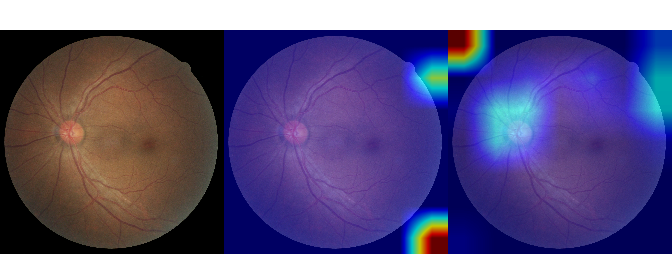

Predicción : Sin RD (prob: 0.92)
Columna 1  : Imagen original
Columna 2  : GradCAM
Columna 3  : GradCAM++

── MODELO MULTICLASE ──


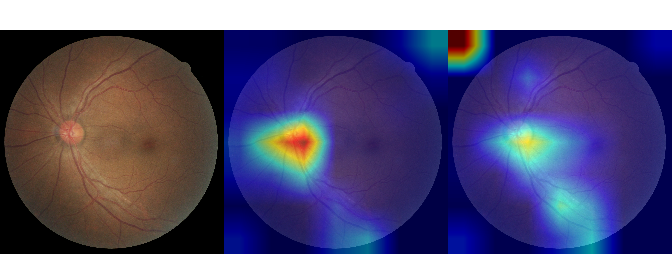

Predicción : Severa (prob: 0.31)
Columna 1  : Imagen original
Columna 2  : GradCAM
Columna 3  : GradCAM++


In [23]:
img_path = str(next((TEST_DIR / '0-noDR').glob('*.jpeg')))

print('── MODELO BINARIO ──')
compare_cam_methods(model_binary, layers_binary,
                    img_path, task='binary')

print('\n── MODELO MULTICLASE ──')
compare_cam_methods(model_multiclass, layers_multiclass,
                    img_path, task='multiclass')

#### 5.3. Aplicación de CAM para cada uno de los grado en el modelo multiclase

En esta sección se definirá la función `cam_all_classes`, que es muy útil para entender qué aprende la red dado que genera un mapa CAM forzando cada clase aunque la imagen sea de grado 0. De esta forma podemos ver qué zonas de la red se activarían para cada grado.

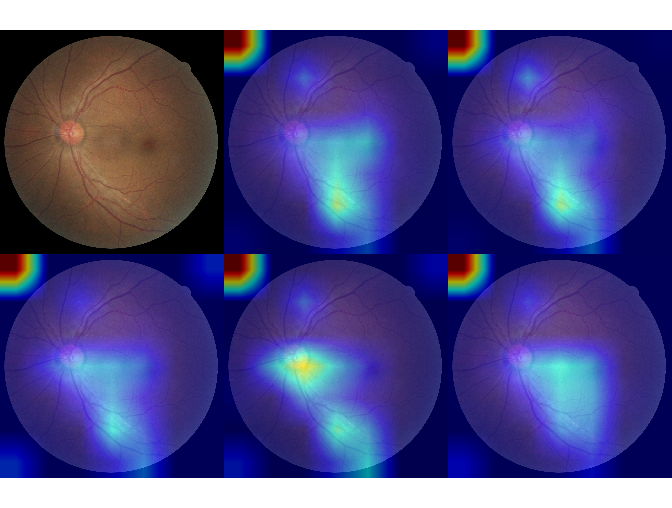

Columnas (izq→der):
  Fila 1: Original | Sin RD    | Leve
  Fila 2: Moderada | Severa    | Proliferativa


In [24]:
def cam_all_classes(model, target_layers, img_path: str):
    """
    Genera un mapa CAM para cada uno de los 5 grados.
    Útil para ver qué busca la red en cada clase.
    """
    _, img_float = preprocess_image(img_path)

    imgs_grid = [PILImage.fromarray(
                    (img_float * 255).astype(np.uint8))]

    for cls_idx, cls_name in GRADES.items():
        overlay, _, _, _, _ = generate_cam(
            model, target_layers, img_path,
            task='multiclass',
            method='gradcam++',
            target_class=cls_idx)
        imgs_grid.append(PILImage.fromarray(overlay))

    w, h  = imgs_grid[0].size
    grid  = PILImage.new('RGB', (w * 3, h * 2 + 60),
                          color=(255, 255, 255))
    for i, im in enumerate(imgs_grid):
        col = i % 3
        row = i // 3
        grid.paste(im, (col * w, row * h + 30))

    display(grid)

    print('Columnas (izq→der):')
    print('  Fila 1: Original | Sin RD    | Leve')
    print('  Fila 2: Moderada | Severa    | Proliferativa')

img_path = str(next((TEST_DIR / '0-noDR').glob('*.jpeg')))
cam_all_classes(model_multiclass, layers_multiclass, img_path)

A continuación, podríamos cambiar la carpeta para ver imágenes de distintos grados y comparar dónde mira la red en cada uno de los casos. Por ejemplo, a continnuación se ha estudiado el caso de la primera imagen de test de la clase `1-mild`.

Imagen: 1216-test/1-mild/2359_right.jpeg

── BINARIO ──


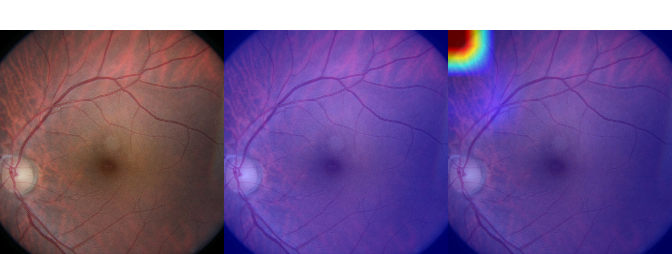

Predicción : Sin RD (prob: 0.86)
Columna 1  : Imagen original
Columna 2  : GradCAM
Columna 3  : GradCAM++

── MULTICLASE ──


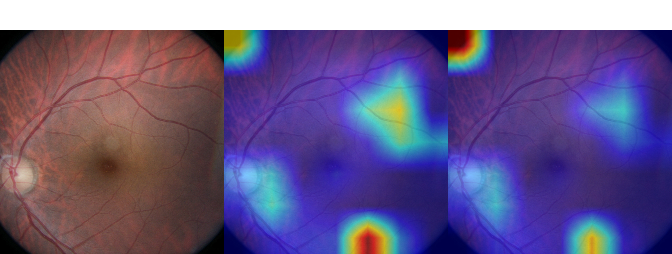

Predicción : Sin RD (prob: 0.40)
Columna 1  : Imagen original
Columna 2  : GradCAM
Columna 3  : GradCAM++

── CAM POR CADA GRADO (multiclase) ──


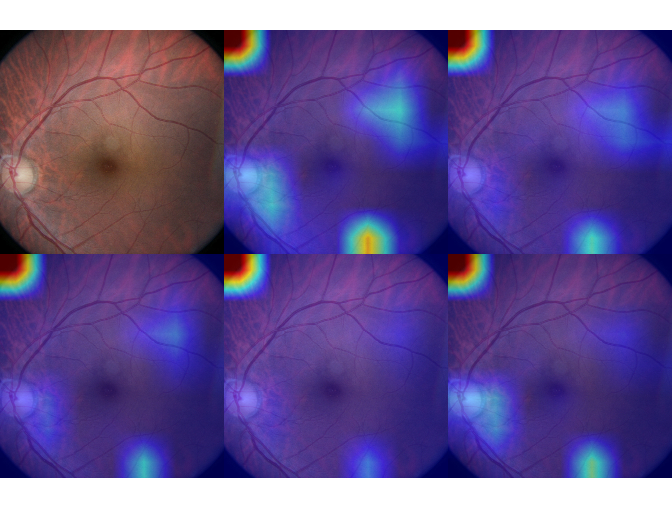

Columnas (izq→der):
  Fila 1: Original | Sin RD    | Leve
  Fila 2: Moderada | Severa    | Proliferativa


In [25]:
FOLDER = '1-mild'
# Opciones: '0-noDR' | '1-mild' | '2-moderate'
#           '3-severe' | '4-proliferativeDR'

img_path = str(next((TEST_DIR / FOLDER).glob('*.jpeg')))
print(f'Imagen: {img_path}\n')

print('── BINARIO ──')
compare_cam_methods(model_binary, layers_binary,
                    img_path, task='binary')

print('\n── MULTICLASE ──')
compare_cam_methods(model_multiclass, layers_multiclass,
                    img_path, task='multiclass')

print('\n── CAM POR CADA GRADO (multiclase) ──')
cam_all_classes(model_multiclass, layers_multiclass, img_path)

### 6. Integrated Gradients

Integrated Gradients es un método de atribución que calcula la contribución de cada píxel integrando los gradientes a lo largo de un camino desde una imagen de referencia (baseline) hasta la imagen de entrada.

A diferencia de Grad-CAM, este método:
* No depende de una capa concreta.
* Proporciona atribuciones a nivel de píxel.
* Tiene fundamentos teóricos sólidos.

En esta sección se implementa este método y se generan mapas de relevancia para analizar qué partes de la imagen influyen en la decisión del modelo.

En primer lugar, definiremos la función `integrated_gradients`, cuyo objetivo es calcular un mapa de importancia por píxel para una imagen y una clase concreta.

In [26]:
def integrated_gradients(
    model,
    input_tensor,
    target_class,
    baseline=None,
    steps=100
):
    model.eval()
    input_tensor = input_tensor.to(DEVICE)

    if baseline is None:
        baseline = torch.zeros_like(input_tensor).to(DEVICE)
    else:
        baseline = baseline.to(DEVICE)

    # Interpolaciones
    scaled_inputs = [
        baseline + (i / steps) * (input_tensor - baseline)
        for i in range(steps + 1)
    ]

    grads = []

    for x in scaled_inputs:
        x.requires_grad_(True)

        output = model(x)

        if output.shape[1] == 1:  # binary
            score = torch.sigmoid(output)[0]
        else:
            score = output[0, target_class]

        model.zero_grad()
        score.backward()

        grads.append(x.grad.detach())

    grads = torch.stack(grads)

    # Regla trapezoidal
    avg_grads = (grads[:-1] + grads[1:]) / 2.0
    avg_grads = avg_grads.mean(dim=0)

    integrated_grads = (input_tensor - baseline) * avg_grads

    return integrated_grads

A continuación, se definirá `generate_integrated_gradients`, que se encargará de ejecutar todo el pipeline:
1. Preprocesa la imagen.
2. Obtiene la predicción.
3. Aplica Integrated Gradients.
4. Convierte el resultado en heatmap.
5. Superpone el heatmap sobre la imagen.

In [27]:
def generate_integrated_gradients(
    model,
    img_path: str,
    task: str,
    target_class: int = None,
    baseline=None,
    steps: int = 100
):
    input_tensor, img_float = preprocess_image(img_path)
    input_tensor = input_tensor.to(DEVICE)

    with torch.no_grad():
        output = model(input_tensor)

        if task == 'binary':
            prob = torch.sigmoid(output).item()
            pred = int(prob > 0.5)
            probs_all = [1 - prob, prob]
        else:
            probs_all = torch.softmax(output, dim=1)[0].cpu().numpy()
            pred = int(np.argmax(probs_all))

    tc = target_class if target_class is not None else pred

    attributions = integrated_gradients(
        model=model,
        input_tensor=input_tensor,
        target_class=tc,
        baseline=baseline,
        steps=steps
    )

    attr = attributions.squeeze().cpu().numpy()

    attr = np.mean(attr, axis=0)

    attr = np.maximum(attr, 0)
    attr = attr / (attr.max() + 1e-8)

    heatmap = cv2.resize(attr, (img_float.shape[1], img_float.shape[0]))

    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0

    overlay = 0.5 * img_float + 0.5 * heatmap_color
    overlay = np.clip(overlay, 0, 1)

    return overlay, heatmap, pred, probs_all, img_float

A continuación, probaremos la función anterior para la primera imagen de la carpeta con las imágenes de test de la clase `0-noDR`.

In [28]:
FOLDER = '0-noDR'
# Opciones: '0-noDR' | '1-mild' | '2-moderate'
#           '3-severe' | '4-proliferativeDR'

img_path = str(next((TEST_DIR / FOLDER).glob('*.jpeg')))
print(f'Imagen: {img_path}\n')

Imagen: 1216-test/0-noDR/216_left.jpeg



── INTEGRATED GRADIENTS ──


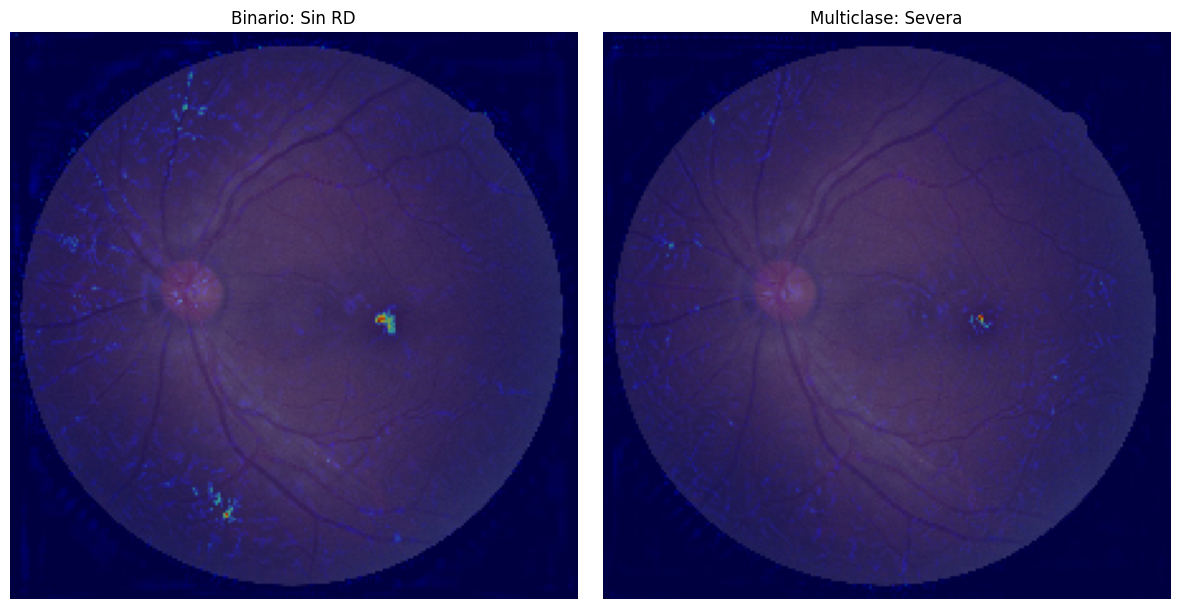

In [29]:
import matplotlib.pyplot as plt

print('── INTEGRATED GRADIENTS ──')

overlay_bin, _, pred_bin, probs_bin, _ = generate_integrated_gradients(
    model_binary,
    img_path,
    task='binary'
)

overlay_multi, _, pred_multi, probs_multi, _ = generate_integrated_gradients(
    model_multiclass,
    img_path,
    task='multiclass'
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(overlay_bin)
axes[0].set_title(f'Binario: {BINARY_LABELS[pred_bin]}')
axes[0].axis('off')

axes[1].imshow(overlay_multi)
axes[1].set_title(f'Multiclase: {GRADES[pred_multi]}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

En el método de Integrated Gradients es necesario definir una imagen de referencia o baseline, que representa la ausencia de información. Tradicionalmente, este baseline se define como una imagen completamente negra (todos los valores a cero). Sin embargo, en el caso de imágenes médicas, esta elección puede no ser la más adecuada.

En este trabajo se utiliza un baseline alternativo basado en una versión difuminada de la imagen original:

In [30]:
def get_blur_baseline(img_float):
    blur = cv2.GaussianBlur(img_float, (51, 51), 0)
    tensor = torch.tensor(blur).permute(2, 0, 1).unsqueeze(0).float()
    return tensor

Por último, volveremos a aplicar Integrated Gradientes utilizando la función baseline anterior.

In [31]:
input_tensor, img_float = preprocess_image(img_path)
baseline = get_blur_baseline(img_float).to(DEVICE)

── INTEGRATED GRADIENTS (WITH BASELINE) ──


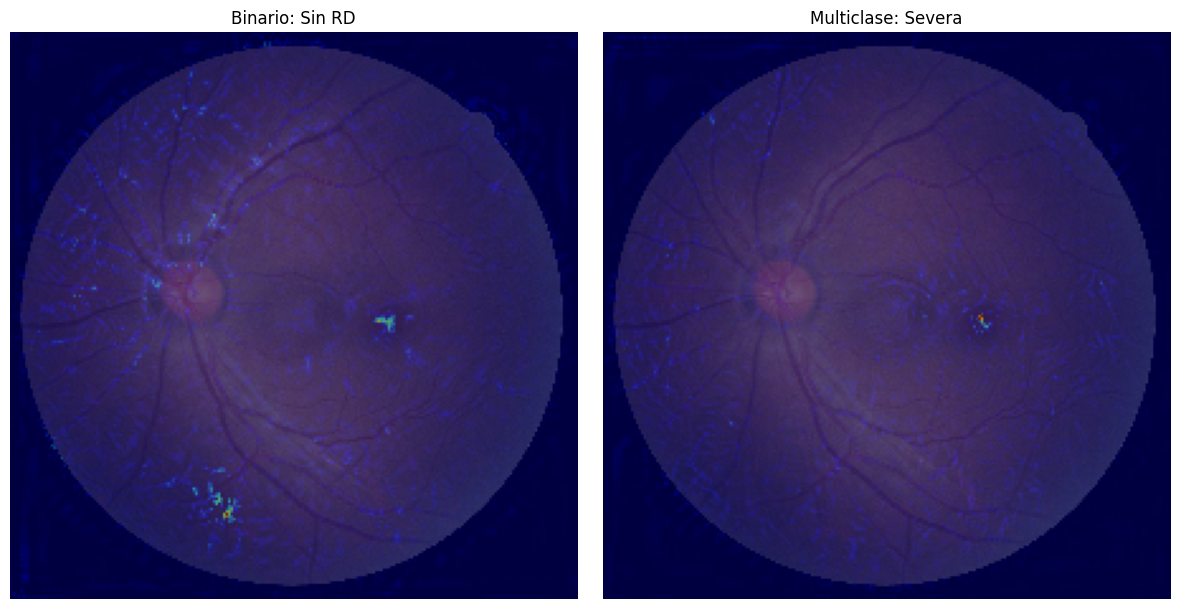

In [32]:
print('── INTEGRATED GRADIENTS (WITH BASELINE) ──')

overlay_bin, _, pred_bin, probs_bin, _ = generate_integrated_gradients(
    model_binary,
    img_path,
    task='binary',
    baseline=baseline
)

overlay_multi, _, pred_multi, probs_multi, _ = generate_integrated_gradients(
    model_multiclass,
    img_path,
    task='multiclass',
    baseline=baseline
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(overlay_bin)
axes[0].set_title(f'Binario: {BINARY_LABELS[pred_bin]}')
axes[0].axis('off')

axes[1].imshow(overlay_multi)
axes[1].set_title(f'Multiclase: {GRADES[pred_multi]}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### 7. Conclusiones

#### 7.1 GradCAM vs GradCAM++

##### Caso Binario

Para la imagen de **grado 0 (Sin RD)**, GradCAM activa dos zonas 
completamente fuera del ojo, en la esquina superior derecha y en la 
esquina inferior derecha, ambas en el fondo negro de la imagen, 
sin ningún contenido retiniano. GradCAM++ mejora parcialmente 
la localización activando la zona superior del disco óptico, 
que sí es una estructura relevante, pero también introduce 
activaciones en las esquinas superior izquierda y 
superior derecha fuera del ojo.

Para la imagen de **grado 1 (Mild)**, GradCAM prácticamente no 
activa ninguna zona (mapa casi completamente azul/frío), lo que 
indica que el modelo no tiene una región de interés clara para 
esta predicción. GradCAM++ en cambio genera una activación muy 
intensa en la esquina superior izquierda, completamente fuera 
del ojo. Esto es especialmente preocupante: el método más 
sofisticado señala con mucha confianza una zona sin contenido 
clínico relevante.

##### Caso Multiclase

Para la imagen de **grado 0**, GradCAM activa la zona 
central de la retina (área macular), que es una región 
clínicamente relevante. GradCAM++ añade a esa activación 
central una zona muy intensa en la esquina superior izquierda 
fuera del ojo, introduciendo ruido en la interpretación.

Para la imagen de **grado 1 (Mild)**, GradCAM distribuye 
las activaciones por varias zonas de la retina. GradCAM++ 
produce un patrón similar pero acentuando de nuevo la 
esquina superior izquierda.

##### Conclusión GradCAM vs GradCAM++

En ambos casos (binario y multiclase) se observa un patrón 
preocupante: tanto GradCAM como GradCAM++ generan activaciones 
fuera del área retiniana. GradCAM++ es teóricamente más preciso 
cuando hay múltiples regiones de interés, pero en este caso 
introduce activaciones espurias más intensas que GradCAM. 
Esto sugiere que el modelo ha aprendido sesgos del dataset, posiblemente relacionados con artefactos del preprocesamiento 
o con la distribución de las imágenes, que ambos métodos 
ponen de manifiesto.

#### 7.2 CAM por cada grado (GradCAM++)

Al forzar GradCAM++ para que genere el mapa de cada uno de 
los 5 grados sobre la misma imagen (tanto para una de clase 0 como para una de clase 1), se observa que 
**todos los grados activan consistentemente la zona superior 
izquierda del ojo**, correspondiente al disco óptico y los 
vasos principales. Esto indica que el modelo usa la misma 
región como referencia independientemente del grado que 
se esté evaluando, lo que no es clínicamente coherente.

Adicionalmente, para la imagen de grado 0 concreta que estamos utilizando, todos los grados 
muestran una pequeña activación espuria en la esquina 
inferior izquierda, fuera del ojo, lo que refuerza la 
hipótesis de un sesgo aprendido durante el entrenamiento.

#### 7.3 Integrated Gradients: sin baseline vs con baseline

Los Integrated Gradients ofrecen un resultado cualitativamente 
muy diferente a los métodos CAM. Tanto sin baseline como con 
baseline, las activaciones son puntuales y muy localizadas 
**dentro del ojo**, señalando pequeñas estructuras que podrían 
corresponder a microaneurismas u otras anomalías vasculares 
propias de la retinopatía diabética. Esto es clínicamente 
mucho más coherente que las activaciones obtenidas con GradCAM.

La diferencia entre usar baseline o no es sutil: con baseline 
(imagen negra como referencia) las activaciones son ligeramente 
más contenidas y el ruido de fondo más uniforme. Dado que el 
fondo de las retinografías es precisamente negro, el baseline 
negro es una elección especialmente adecuada para este dominio, 
ya que la referencia coincide con el fondo real de la imagen.

#### 7.4 CAM vs Integrated Gradients

| Aspecto | GradCAM / GradCAM++ | Integrated Gradients |
|---|---|---|
| Granularidad | Baja (regiones amplias) | Alta (píxeles individuales) |
| Localización | Fuera y dentro del ojo | Dentro del ojo |
| Activaciones espurias | Sí, consistentes | No observadas |
| Coherencia clínica | Cuestionable | Alta |
| Coste computacional | Bajo | Medio |

GradCAM y GradCAM++ son rápidos y fáciles de aplicar, pero 
en este caso han revelado un comportamiento preocupante: el 
modelo activa zonas fuera del área retiniana de forma 
consistente, lo que sugiere que ha aprendido atajos 
estadísticos en lugar de características clínicamente 
relevantes.

Los Integrated Gradients, en cambio, señalan estructuras 
puntuales dentro de la retina que tienen una interpretación 
clínica directa. Son más lentos computacionalmente pero 
ofrecen una explicabilidad más fiable y granular.

#### 7.5 Conclusión General

Los resultados de interpretabilidad revelan que el modelo 
presenta **sesgos aprendidos**: tanto GradCAM como GradCAM++ 
muestran activaciones fuera del ojo de forma consistente 
en ambas tareas (binaria y multiclase), lo que indica que 
el modelo no está mirando únicamente las estructuras 
retinianas para tomar sus decisiones.

Los Integrated Gradients ofrecen una imagen más fiable 
del comportamiento del modelo, señalando estructuras 
internas de la retina coherentes con los hallazgos 
clínicos de la retinopatía diabética.

Para mejorar estos resultados se podría:
- **Ampliar el dataset** para reducir sesgos estadísticos.
- **Aplicar un enmascaramiento circular** de la retina 
  durante el preprocesamiento para eliminar el fondo negro.
- **Combinar varios métodos de explicabilidad** para 
  obtener una visión más completa del comportamiento 
  del modelo.